In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
# age = It is the age of patient
# sex = It is Gender of the patient ( 0 for female , 1 for male )
# cp = Chest pain of patient ( 1 level , 2 level )
# trestbps = Blood pressure in resting condition
# chol = cholesterol level at admission at hospital
# fbs = Fasting blood sugar level
# restecg = ECG ( Electrocardio graphy ) level at resting
# thalach = Maximm heart rate achieved during the test
# exang =  Exercise Induced angina  ( Facing any discomfor or not)
# oldpeak = How much ECG changes dusring exercise as compared to rest
# slope = Slope of ECG or ST changes
# ca ( coronary artery ) = The number of major blood vessels ( 0-3)  colored by fluoroscopy
# thal ( thalassemia ) = A blood disorder that can damage your heart

# target = whether a patient is having heart disease or not , 1 for Yes , 0 for No

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df['target'].value_counts()
# 1 means - YES having a heart deasis 
# 0 means - NO having no heart deasis 

target
1    165
0    138
Name: count, dtype: int64

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

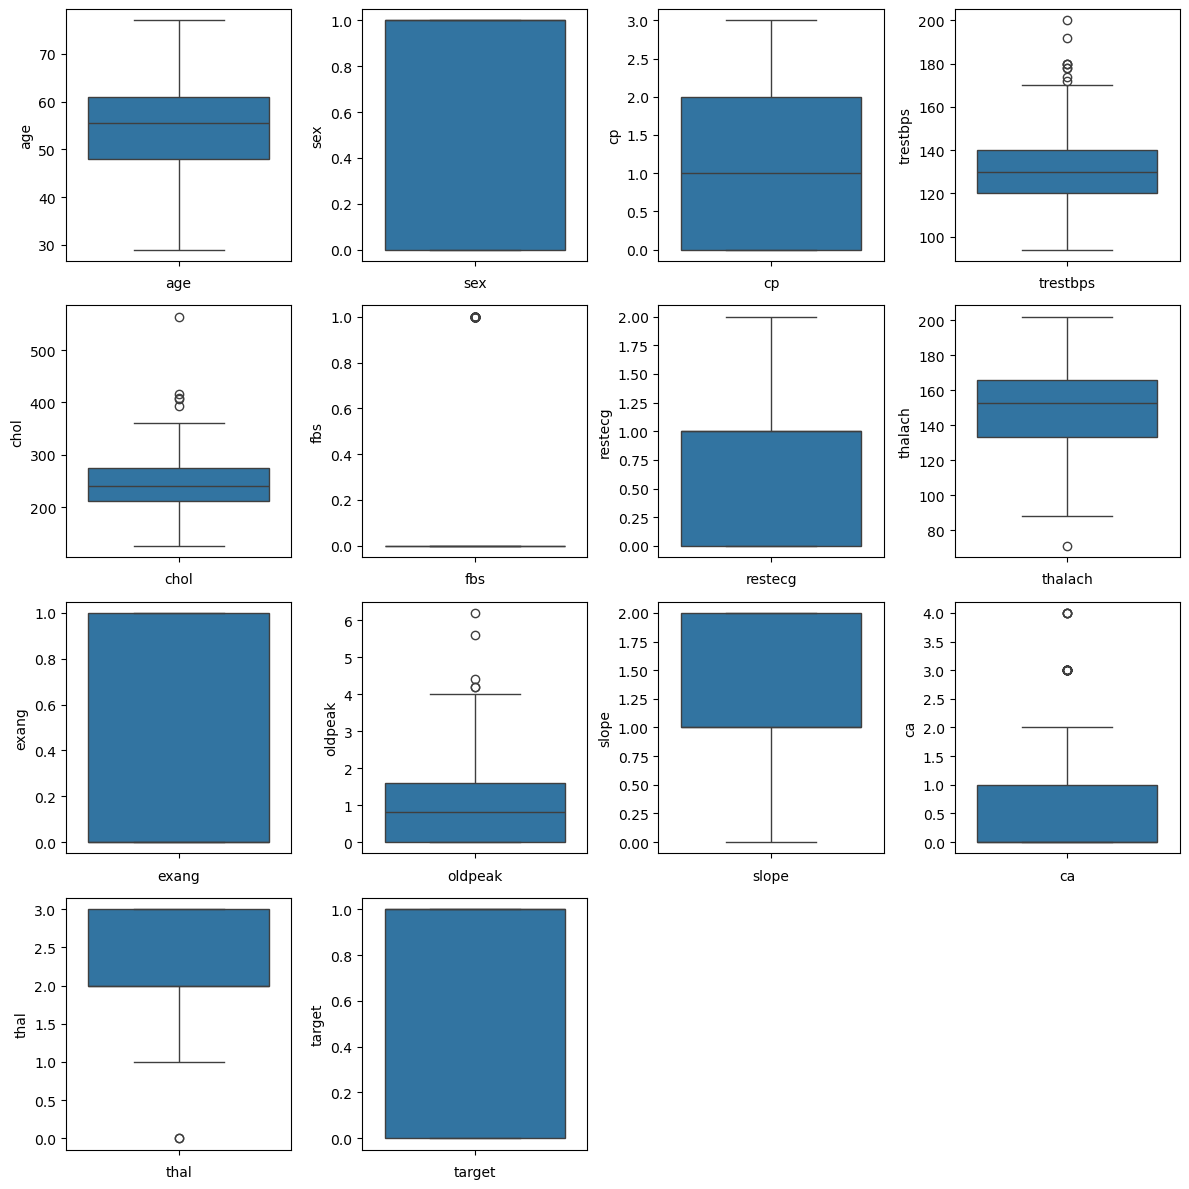

In [10]:
plt.figure(figsize=(12,12))
z = 1
for i in df.columns:
    if df[i].dtype != 'object':
        plt.subplot(4,4,z)
        sns.boxplot(df[i])
        plt.xlabel(i)
        z+=1
plt.tight_layout()
plt.show()

In [11]:
# as the dataset is of real paitents dataset we are not going to remove the outliers in the dataset 
# any tree algo is not effected by the outliers we can skip the oulier removal part 

In [12]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [13]:
# independent variables 
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [14]:
# dependent variable 
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 302, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=1,test_size=0.2)

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dt = DecisionTreeClassifier()

In [19]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [20]:
y_predict = dt.predict(x_test)

In [21]:
act_pred = pd.DataFrame()
act_pred['actual'] = y_test
act_pred['predicted'] = y_predict
act_pred

,actual,predicted
174,0,0
88,1,1
163,1,1
243,0,0
110,1,0
...,...,...
194,0,0
78,1,1
248,0,1
220,0,0


In [22]:
from sklearn.metrics import *

In [23]:
accuracy_score(act_pred['actual'],act_pred['predicted'])

0.7377049180327869

In [24]:
confusion_matrix(act_pred['actual'],act_pred['predicted'])

array([[22,  7],
       [ 9, 23]])

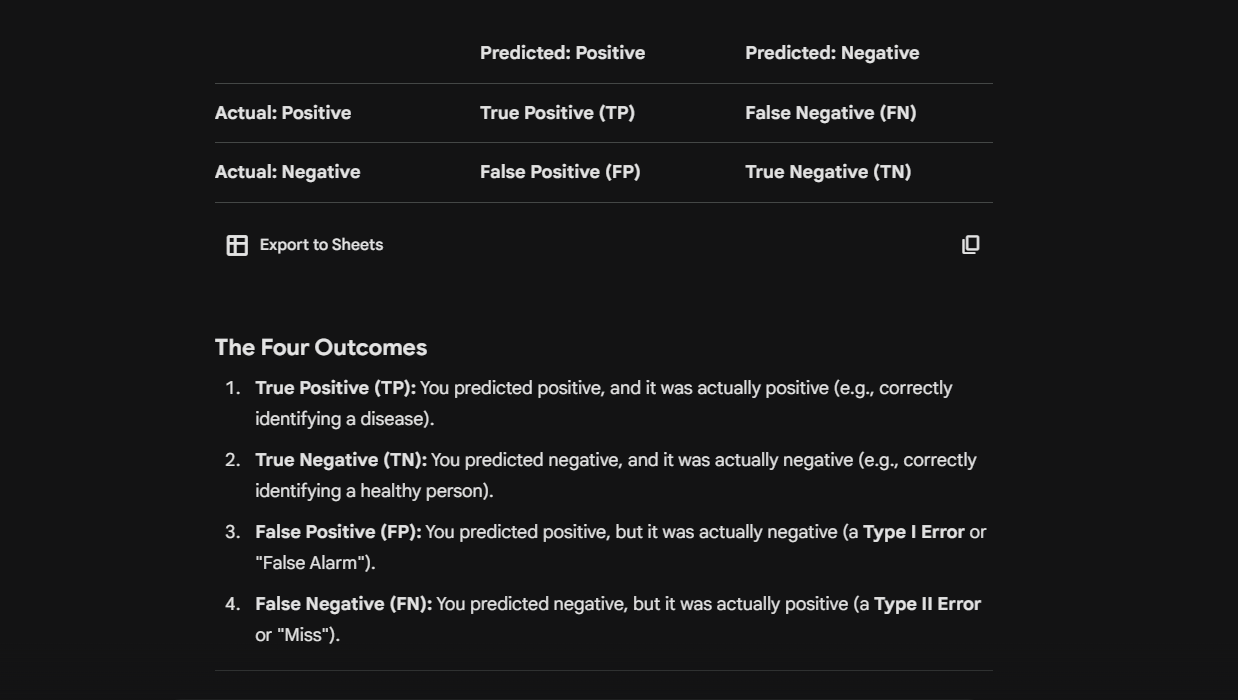

In [25]:
# 1. Accuracy Score: How many correct prediction my model has got out of all the
# predictions.

# Formula: TP+TN /TP+FP+FN+TN

# 2. Precision Score: How many of the predicted positive cases were actually positive.

# Formual: TP/TP+FP

# 3. Recall Score: How many actual positive cases my model is able to catch

# Formula: TP/TP+FN

In [26]:
recall_score(act_pred['actual'],act_pred['predicted'])

0.71875

In [27]:
precision_score(act_pred['actual'],act_pred['predicted'])

0.7666666666666667

In [28]:
from sklearn import tree

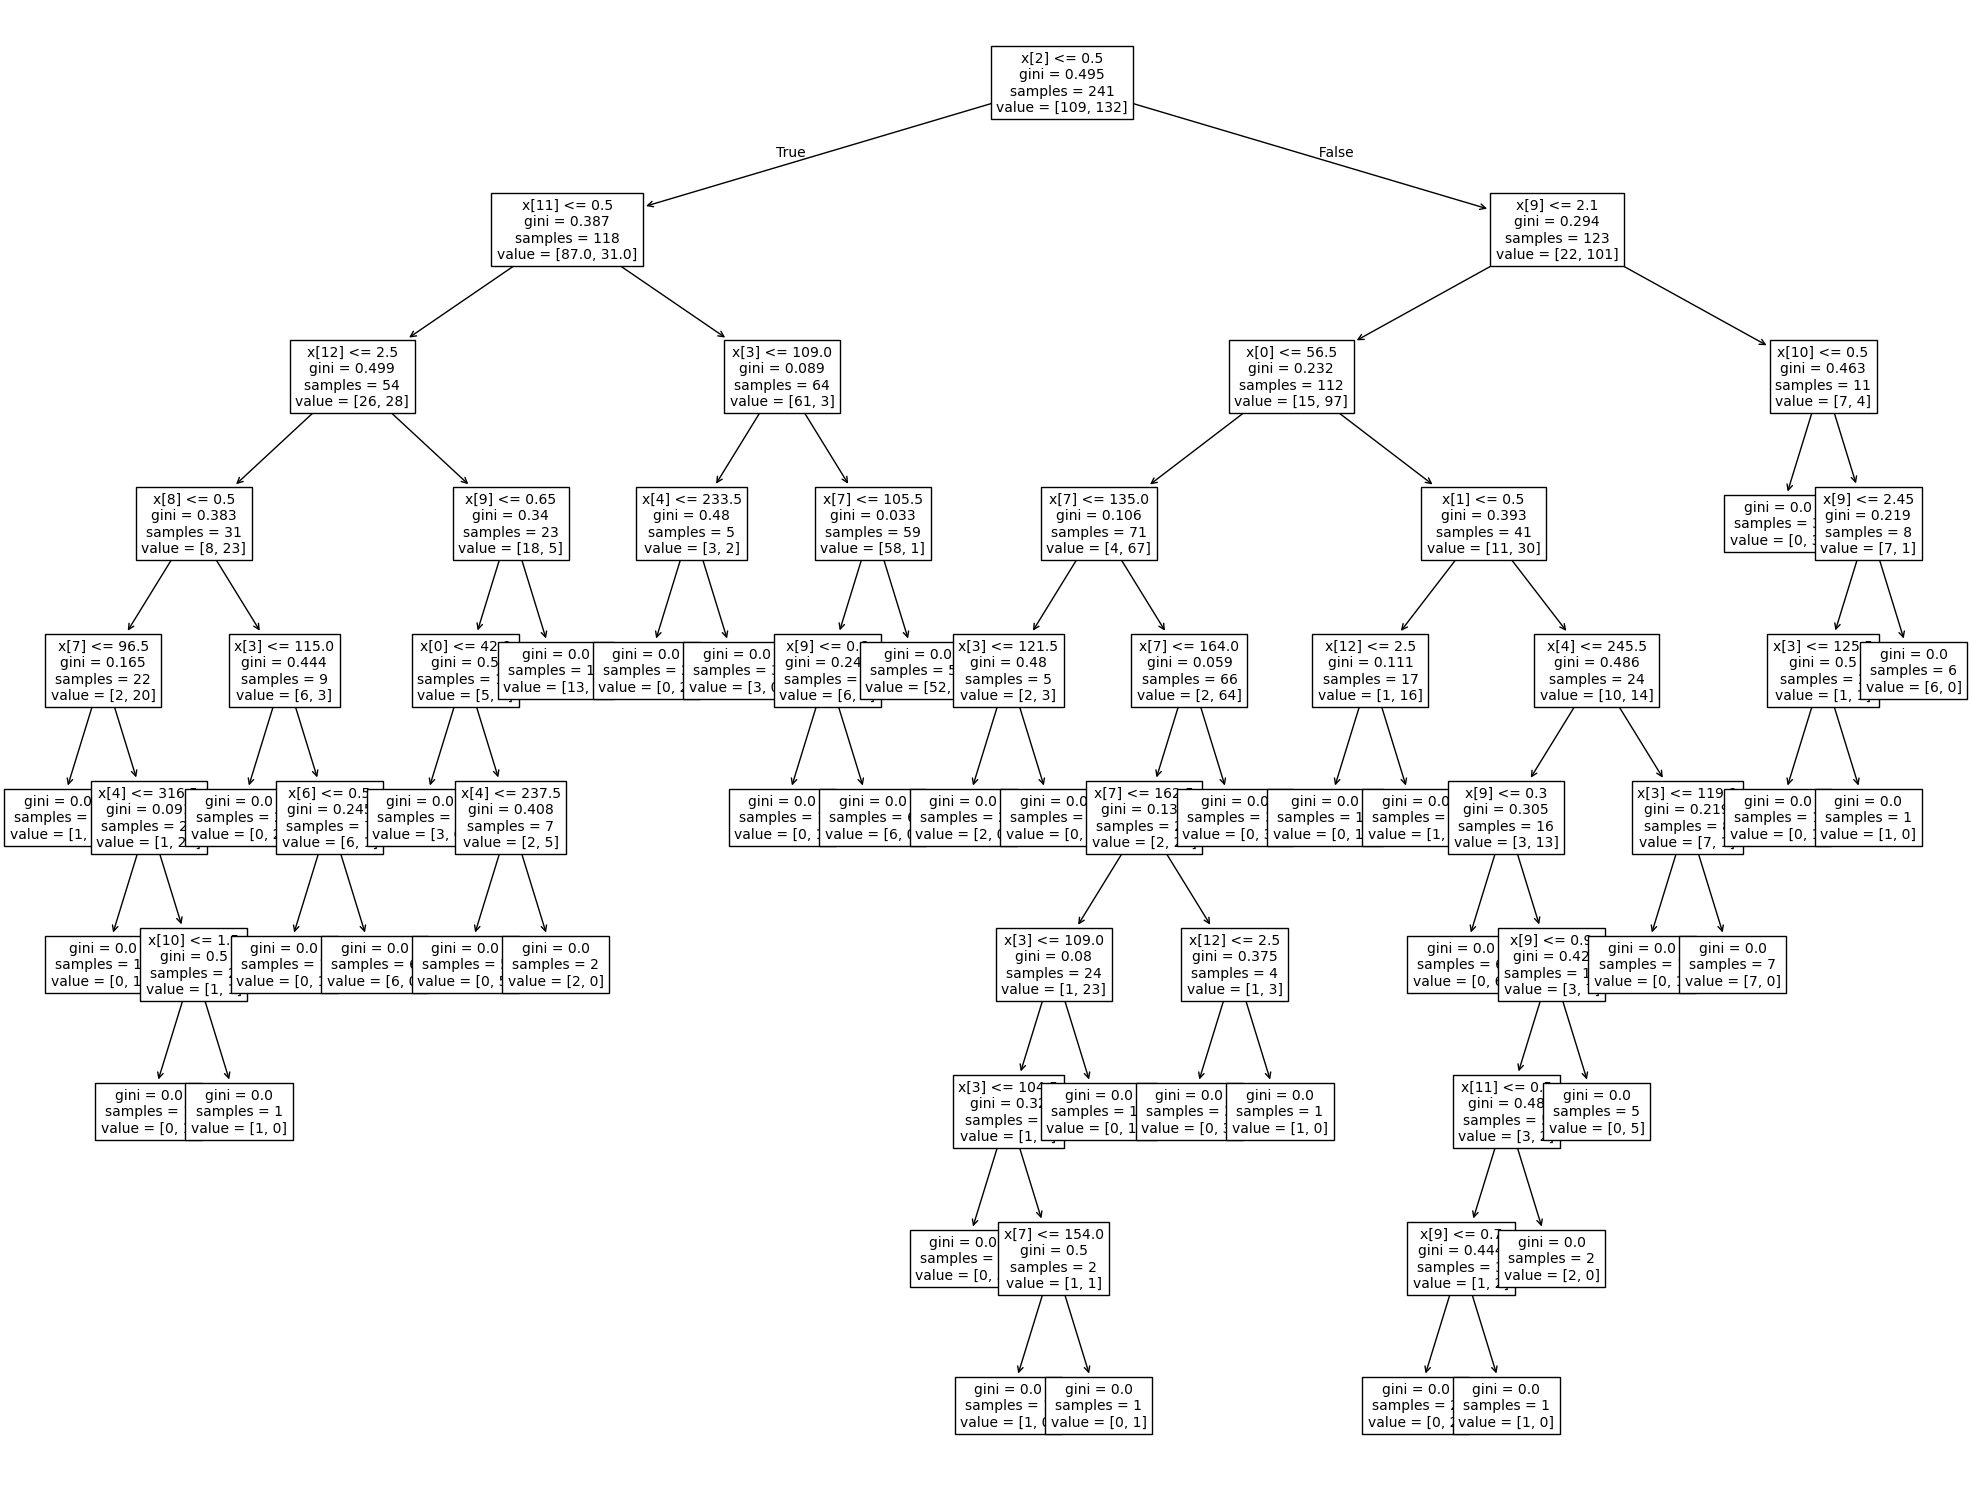

In [29]:
plt.figure(figsize=(20,15))
tree.plot_tree(dt,fontsize=10)
plt.tight_layout()
plt.show()

In [30]:
dt.get_depth()
# position of the leaf node 

9

In [31]:
# Max_Depth is a hyperparameter used in decision tree.It controls how deep the tree can split the data 

In [32]:
depths = np.arange(1,11,1)
depths

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [33]:
for i in depths:
    dt = DecisionTreeClassifier(max_depth=i,random_state=41)
    dt.fit(x_train,y_train)
    y_pred = dt.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    print(f'for max depth = {i} accuracy = {acc}')

for max depth = 1 accuracy = 0.6721311475409836
for max depth = 2 accuracy = 0.6885245901639344
for max depth = 3 accuracy = 0.7704918032786885
for max depth = 4 accuracy = 0.7213114754098361
for max depth = 5 accuracy = 0.7377049180327869
for max depth = 6 accuracy = 0.7704918032786885
for max depth = 7 accuracy = 0.7704918032786885
for max depth = 8 accuracy = 0.7704918032786885
for max depth = 9 accuracy = 0.7540983606557377
for max depth = 10 accuracy = 0.7540983606557377
